# XGBoost — Baseline vs. EIA-Augmented Comparison

This notebook trains two identical XGBoost pipelines side-by-side and measures the incremental value of EIA petroleum inventory features for WTI crude oil direction prediction.

| Model | Features | Target |
|-------|----------|--------|
| **Baseline** | 31 FRED-MD macro × 30 lags + 30 price lags = 960 features | Next-day WTI direction (±1) |
| **EIA-Augmented** | Baseline + 7 EIA inventory features = 967 features | Same |

**Fair comparison guarantees:**
- Identical training rows and date ranges: train ≤ 2014-12-31, val 2015–2024, test 2025+
- Same 6-config hyperparameter grid and 5-fold `TimeSeriesSplit` CV
- Independent threshold tuning per model on validation set only
- XGBoost native NaN handling for pre-2004 Cushing features (no imputation)
- Both models inherit `BaseForecastModel` with a full `fit()` implementation

## 0. Setup

In [1]:
import sys, pickle, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, roc_auc_score
)
import xgboost as xgb

sys.path.insert(0, str(Path("..").resolve()))
from model_classes import BaseForecastModel, evaluate_classification
from data_utils import build_dataset

EIA_CSV  = Path("data/eia_features_daily.csv")
PRED_DIR = Path("..") / "predictions"
PRED_DIR.mkdir(exist_ok=True)
warnings.filterwarnings("ignore")

# ── GPU auto-detection ────────────────────────────────────────────────────────
def _detect_gpu_params():
    _major = int(xgb.__version__.split(".")[0])
    gpu_p  = {"device": "cuda"} if _major >= 2 else {"tree_method": "gpu_hist"}
    try:
        probe = xgb.XGBClassifier(**gpu_p, n_estimators=1, verbosity=0)
        probe.fit([[0, 1], [1, 0]], [0, 1])
        print(f"[GPU] XGBoost {xgb.__version__} — CUDA enabled")
        return gpu_p
    except Exception:
        print(f"[CPU] XGBoost {xgb.__version__} — GPU unavailable, using hist")
        return {"tree_method": "hist"}

XGB_DEVICE = _detect_gpu_params()

[GPU] XGBoost 3.2.0 — CUDA enabled


## 1. Data Loading

`build_dataset()` constructs the standard 960-feature matrix (31 FRED-MD variables × 30 lags + 30 price lags) with the chronological train/val/test split. EIA features are joined on the date index using a **left join** so both models train on exactly the same rows.

The four Cushing-derived features (`cushing_chg`, `cushing_4wma`, `cushing_zscore`, `surprise`) are NaN before April 2004 — XGBoost handles this natively by learning the optimal split direction for missing values. The non-Cushing features (`total_chg`, `gasoline_chg`, `distill_chg`) are available from the early 1980s.

Critically, both val (2015–2024) and test (2025+) periods have **zero NaNs** in all EIA features, so the evaluation comparison is entirely clean.

In [30]:
X_tr, y_tr, X_val, y_val, X_te, y_te = build_dataset()

eia      = pd.read_csv(EIA_CSV, index_col="Date", parse_dates=True)
EIA_COLS = list(eia.columns)

X_tr_eia  = X_tr.join(eia,  how="left")
X_val_eia = X_val.join(eia, how="left")
X_te_eia  = X_te.join(eia,  how="left")

assert X_tr.shape[0] == X_tr_eia.shape[0], "Row count mismatch — check join"

print(f"Baseline features  : {X_tr.shape[1]}")
print(f"EIA-augmented      : {X_tr_eia.shape[1]}  (+{len(EIA_COLS)} EIA features)")
print(f"\nEIA NaN counts — TRAIN (pre-2004 Cushing gap expected):")
print(X_tr_eia[EIA_COLS].isna().sum().to_string())
print(f"\nEIA NaN counts — VAL (should all be 0):")
print(X_val_eia[EIA_COLS].isna().sum().to_string())
print(f"\nEIA NaN counts — TEST (should all be 0):")
print(X_te_eia[EIA_COLS].isna().sum().to_string())

Dataset sizes  — Train: 7954  Val: 2635  Test: 216
Feature matrix — 10805 rows x 960 cols
Class balance  — Up: 5509  Down: 5296
Date range     — 1983-05-13 to 2025-10-31
Baseline features  : 960
EIA-augmented      : 967  (+7 EIA features)

EIA NaN counts — TRAIN (pre-2004 Cushing gap expected):
cushing_chg       5243
total_chg            0
gasoline_chg      1670
distill_chg          0
cushing_4wma      5242
cushing_zscore    5267
surprise          5243

EIA NaN counts — VAL (should all be 0):
cushing_chg       0
total_chg         0
gasoline_chg      0
distill_chg       0
cushing_4wma      0
cushing_zscore    0
surprise          0

EIA NaN counts — TEST (should all be 0):
cushing_chg       0
total_chg         0
gasoline_chg      0
distill_chg       0
cushing_4wma      0
cushing_zscore    0
surprise          0


## 2. Model Class

`XGBoostDirectionClassifier` inherits from `BaseForecastModel` and implements a full `fit()` with:
- **5-fold TimeSeriesSplit grid search** over 6 hyperparameter configurations
- `eval_metric="error"` (not logloss) to prevent degenerate solutions on near-random signals
- `scale_pos_weight` computed per fold from the training class ratio to handle imbalance
- **Early stopping** (`rounds=100`) on the held-out validation set after refitting on full training data

The same class is instantiated twice — once for baseline features, once for EIA-augmented features — with no other differences.

In [31]:
# param_grid matches XGBoost_Direction_VIP.ipynb exactly — min_child_weight is
# critical: without it (default=1) trees overfit noise immediately, validation
# error never improves past round 1, and early stopping produces a near-trivial
# model that predicts Up almost exclusively.
PARAM_GRID = [
    {"max_depth": 2, "learning_rate": 0.05, "subsample": 0.8,
     "colsample_bytree": 0.7, "min_child_weight": 5,
     "gamma": 0.1, "reg_alpha": 0.1, "reg_lambda": 2.0},
    {"max_depth": 3, "learning_rate": 0.03, "subsample": 0.8,
     "colsample_bytree": 0.8, "min_child_weight": 3,
     "gamma": 0.0, "reg_alpha": 0.0, "reg_lambda": 1.0},
    {"max_depth": 3, "learning_rate": 0.05, "subsample": 0.7,
     "colsample_bytree": 0.7, "min_child_weight": 5,
     "gamma": 0.0, "reg_alpha": 0.1, "reg_lambda": 1.0},
    {"max_depth": 4, "learning_rate": 0.03, "subsample": 0.8,
     "colsample_bytree": 0.8, "min_child_weight": 3,
     "gamma": 0.1, "reg_alpha": 0.0, "reg_lambda": 2.0},
    {"max_depth": 4, "learning_rate": 0.05, "subsample": 0.7,
     "colsample_bytree": 0.7, "min_child_weight": 5,
     "gamma": 0.0, "reg_alpha": 1.0, "reg_lambda": 1.0},
    {"max_depth": 5, "learning_rate": 0.03, "subsample": 0.8,
     "colsample_bytree": 0.8, "min_child_weight": 5,
     "gamma": 0.5, "reg_alpha": 0.1, "reg_lambda": 2.0},
]


class XGBoostDirectionClassifier(BaseForecastModel):
    """XGBoost binary direction classifier with TimeSeriesSplit grid search.

    eval_metric="error" is intentional — NOT logloss.
    With a near-50% signal, logloss is minimised by outputting p≈0.51
    everywhere (always-Up), causing early stopping to fire at a degenerate
    solution. Error metric directly optimises accuracy, which is what we
    report and what matters for directional trading.

    min_child_weight (3 or 5 per config) is essential: without it (default=1)
    trees overfit noise splits immediately and early stopping sees no
    validation improvement past round 1.
    """

    def __init__(self, n_splits=5, num_boost_round=1000, early_stopping_rounds=100):
        super().__init__("classification")
        self.n_splits               = n_splits
        self.num_boost_round        = num_boost_round
        self.early_stopping_rounds  = early_stopping_rounds
        self.model                  = None
        self.best_params_           = None
        self.cv_results_            = []
        self.eval_results_          = {}
        self.feature_names_         = None
        self.threshold_             = 0.5

    @staticmethod
    def _to_binary(y):  return ((np.asarray(y) + 1) // 2).astype(int)
    @staticmethod
    def _to_signed(y):  return np.where(np.asarray(y) == 1, 1, -1)

    def fit(self, X_train, y_train, X_val, y_val):
        self.feature_names_ = list(X_train.columns)
        y_tr01  = self._to_binary(y_train)
        y_val01 = self._to_binary(y_val)
        tscv    = TimeSeriesSplit(n_splits=self.n_splits)
        t0_total = time.time()

        best_score = -1
        for cfg_i, cfg in enumerate(PARAM_GRID, 1):
            t0_cfg = time.time()
            fold_accs = []
            for fold_i, (fold_tr, fold_va) in enumerate(tscv.split(X_train), 1):
                Xf_tr, Xf_va = X_train.iloc[fold_tr], X_train.iloc[fold_va]
                yf_tr, yf_va = y_tr01[fold_tr],       y_tr01[fold_va]
                spw = max((yf_tr == 0).sum() / max((yf_tr == 1).sum(), 1), 1e-3)
                m = xgb.XGBClassifier(
                    **cfg, **XGB_DEVICE,
                    n_estimators=self.num_boost_round,
                    objective="binary:logistic",
                    eval_metric="error",
                    early_stopping_rounds=self.early_stopping_rounds,
                    scale_pos_weight=spw,
                    verbosity=0,
                )
                m.fit(Xf_tr, yf_tr, eval_set=[(Xf_va, yf_va)], verbose=False)
                fold_accs.append(accuracy_score(yf_va, m.predict(Xf_va)))
                print(f"  config {cfg_i}/6  fold {fold_i}/5  "
                      f"acc={fold_accs[-1]:.4f}  rounds={m.best_iteration+1}", flush=True)
            mean_acc = np.mean(fold_accs)
            elapsed  = time.time() - t0_cfg
            print(f"  config {cfg_i}/6 DONE — mean_cv_acc={mean_acc:.4f}  ({elapsed:.1f}s)\n", flush=True)
            self.cv_results_.append({"params": cfg, "cv_accuracy": mean_acc})
            if mean_acc > best_score:
                best_score, self.best_params_ = mean_acc, cfg

        print(f"Grid search complete in {time.time()-t0_total:.1f}s")
        print(f"Best CV accuracy : {best_score:.4f}")
        print(f"Best params      : {self.best_params_}")

        # Final refit on full training data with early stopping on val set
        spw_final = max((y_tr01 == 0).sum() / max((y_tr01 == 1).sum(), 1), 1e-3)
        print("\nFinal refit on full training set (verbose every 50 rounds)...", flush=True)
        t0_refit = time.time()
        self.model = xgb.XGBClassifier(
            **self.best_params_, **XGB_DEVICE,
            n_estimators=self.num_boost_round,
            objective="binary:logistic",
            eval_metric="error",
            early_stopping_rounds=self.early_stopping_rounds,
            scale_pos_weight=spw_final,
            verbosity=0,
        )
        self.model.fit(
            X_train, y_tr01,
            eval_set=[(X_train, y_tr01), (X_val, y_val01)],
            verbose=50,
        )
        self.eval_results_ = self.model.evals_result()
        print(f"Refit done in {time.time()-t0_refit:.1f}s  |  best iteration: {self.model.best_iteration}", flush=True)

    def tune_threshold(self, X_val, y_val):
        prob = self.predict_proba(X_val)
        best_t, best_acc = 0.5, 0.0
        for t in np.linspace(0.30, 0.70, 41):
            acc = accuracy_score(y_val, self._to_signed((prob >= t).astype(int)))
            if acc > best_acc:
                best_acc, best_t = acc, t
        self.threshold_ = best_t
        print(f"Tuned threshold  : {best_t:.2f}  (val accuracy {best_acc:.4f})")

    def predict_proba(self, X):
        Xv = X.values if hasattr(X, "values") else X
        return self.model.predict_proba(Xv)[:, 1]

    def predict(self, X, threshold=None):
        t = threshold if threshold is not None else self.threshold_
        return self._to_signed((self.predict_proba(X) >= t).astype(int))

    def evaluate(self, X, y, label=""):
        yt = y.values if hasattr(y, "values") else y
        return evaluate_classification(yt, self.predict(X), self.predict_proba(X), label=label)

    def save(self, filepath):
        with open(filepath, "wb") as f:
            pickle.dump(self.__dict__, f)

    def load(self, filepath):
        with open(filepath, "rb") as f:
            self.__dict__.update(pickle.load(f))

## 3. Baseline XGBoost — No EIA Features

Trained on the standard 960-feature matrix. This is the reference point for evaluating what the EIA features add.

In [32]:
print("=" * 60)
print("BASELINE XGBoost  (960 features, no EIA)")
print("=" * 60)
clf_base = XGBoostDirectionClassifier()
clf_base.fit(X_tr, y_tr, X_val, y_val)
clf_base.tune_threshold(X_val, y_val)
clf_base.save(str(Path("..") / "xgboost_baseline_eia_comparison.pkl"))
print("\nBaseline training complete.")

BASELINE XGBoost  (960 features, no EIA)
  config 1/6  fold 1/5  acc=0.5238  rounds=13
  config 1/6  fold 2/5  acc=0.5253  rounds=11
  config 1/6  fold 3/5  acc=0.5200  rounds=1
  config 1/6  fold 4/5  acc=0.5245  rounds=5
  config 1/6  fold 5/5  acc=0.5162  rounds=1
  config 1/6 DONE — mean_cv_acc=0.5220  (8.6s)

  config 2/6  fold 1/5  acc=0.5268  rounds=149
  config 2/6  fold 2/5  acc=0.5351  rounds=213
  config 2/6  fold 3/5  acc=0.5238  rounds=1
  config 2/6  fold 4/5  acc=0.5275  rounds=24
  config 2/6  fold 5/5  acc=0.5170  rounds=16
  config 2/6 DONE — mean_cv_acc=0.5260  (13.1s)

  config 3/6  fold 1/5  acc=0.5283  rounds=26
  config 3/6  fold 2/5  acc=0.5343  rounds=219
  config 3/6  fold 3/5  acc=0.5026  rounds=161
  config 3/6  fold 4/5  acc=0.5245  rounds=33
  config 3/6  fold 5/5  acc=0.5185  rounds=68
  config 3/6 DONE — mean_cv_acc=0.5217  (15.6s)

  config 4/6  fold 1/5  acc=0.5291  rounds=79
  config 4/6  fold 2/5  acc=0.5298  rounds=51
  config 4/6  fold 3/5  acc=0.5

## 4. EIA-Augmented XGBoost — +7 EIA Features

Identical pipeline, identical hyperparameter search space, but trained on the 967-feature matrix that includes EIA inventory features. The model independently selects its own best hyperparameters and threshold.

In [33]:
print("=" * 60)
print("EIA-AUGMENTED XGBoost  (967 features, +7 EIA)")
print("=" * 60)
clf_eia = XGBoostDirectionClassifier()
clf_eia.fit(X_tr_eia, y_tr, X_val_eia, y_val)
clf_eia.tune_threshold(X_val_eia, y_val)
clf_eia.save(str(Path("..") / "xgboost_eia_augmented.pkl"))
print("\nEIA-augmented training complete.")

EIA-AUGMENTED XGBoost  (967 features, +7 EIA)
  config 1/6  fold 1/5  acc=0.5200  rounds=11
  config 1/6  fold 2/5  acc=0.5291  rounds=20
  config 1/6  fold 3/5  acc=0.5260  rounds=1
  config 1/6  fold 4/5  acc=0.5268  rounds=5
  config 1/6  fold 5/5  acc=0.5200  rounds=4
  config 1/6 DONE — mean_cv_acc=0.5244  (8.2s)

  config 2/6  fold 1/5  acc=0.5223  rounds=13
  config 2/6  fold 2/5  acc=0.5321  rounds=6
  config 2/6  fold 3/5  acc=0.5381  rounds=1
  config 2/6  fold 4/5  acc=0.5162  rounds=11
  config 2/6  fold 5/5  acc=0.5291  rounds=8
  config 2/6 DONE — mean_cv_acc=0.5275  (10.0s)

  config 3/6  fold 1/5  acc=0.5238  rounds=7
  config 3/6  fold 2/5  acc=0.5238  rounds=43
  config 3/6  fold 3/5  acc=0.5162  rounds=129
  config 3/6  fold 4/5  acc=0.5275  rounds=10
  config 3/6  fold 5/5  acc=0.5185  rounds=6
  config 3/6 DONE — mean_cv_acc=0.5220  (11.4s)

  config 4/6  fold 1/5  acc=0.5200  rounds=12
  config 4/6  fold 2/5  acc=0.5245  rounds=94
  config 4/6  fold 3/5  acc=0.529

## 5. Results Comparison

We evaluate both models on the **validation set (2015–2024)** and the **held-out test set (2025+)**. The delta column (EIA − Baseline) on the test set isolates the marginal contribution of EIA features. All evaluation uses each model's independently tuned threshold.

In [34]:
results = {}
for clf, tag, Xv, Xt in [
    (clf_base, "Baseline", X_val,     X_te),
    (clf_eia,  "EIA",      X_val_eia, X_te_eia),
]:
    results[f"{tag} Val"]  = clf.evaluate(Xv, y_val, label=f"{tag} — Validation")
    results[f"{tag} Test"] = clf.evaluate(Xt, y_te,  label=f"{tag} — Test")

COLS = ["accuracy", "roc_auc", "f1_down", "f1_up", "f1_weighted"]
metrics_df = pd.DataFrame(results, index=COLS).T.round(4)

# Delta: EIA Test − Baseline Test
delta = (metrics_df.loc["EIA Test"] - metrics_df.loc["Baseline Test"]).rename("Δ (EIA−Base) Test")
display_df = pd.concat([metrics_df, delta.to_frame().T])
print(display_df.to_string())


  Baseline — Validation
              precision    recall  f1-score   support

   Down (-1)       0.62      0.01      0.03      1240
     Up (+1)       0.53      0.99      0.69      1395

    accuracy                           0.53      2635
   macro avg       0.58      0.50      0.36      2635
weighted avg       0.57      0.53      0.38      2635

  ROC-AUC : 0.5199
  F1 (wtd): 0.3796

  Baseline — Test
              precision    recall  f1-score   support

   Down (-1)       1.00      0.02      0.04       109
     Up (+1)       0.50      1.00      0.67       107

    accuracy                           0.50       216
   macro avg       0.75      0.51      0.35       216
weighted avg       0.75      0.50      0.35       216

  ROC-AUC : 0.5349
  F1 (wtd): 0.3484

  EIA — Validation
              precision    recall  f1-score   support

   Down (-1)       0.51      0.43      0.47      1240
     Up (+1)       0.56      0.64      0.59      1395

    accuracy                           0.5

## 6. Confusion Matrices

Confusion matrices show the breakdown of correct and incorrect directional calls. We compare validation (in-sample for threshold tuning) and test (strictly out-of-sample) for both models. Row = actual, column = predicted.

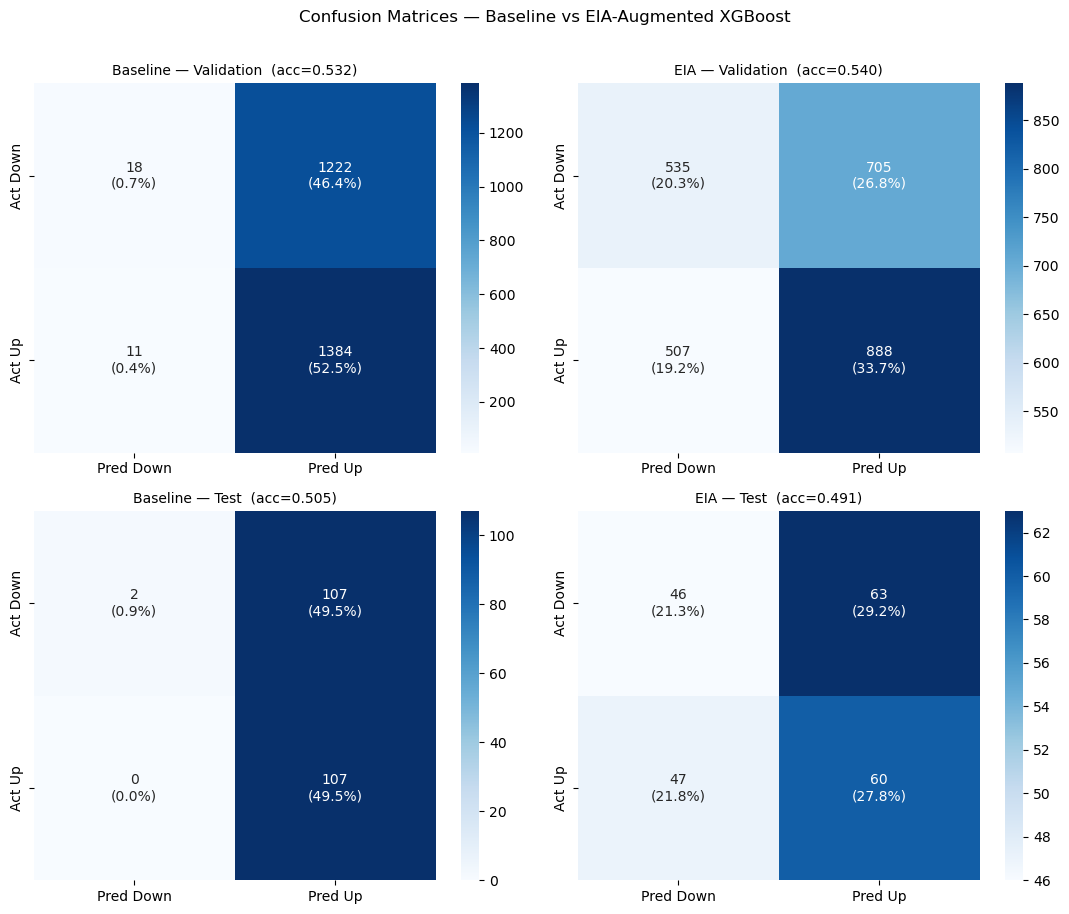

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
panels = [
    (clf_base, X_val,     y_val, "Baseline — Validation",  axes[0, 0]),
    (clf_eia,  X_val_eia, y_val, "EIA — Validation",       axes[0, 1]),
    (clf_base, X_te,      y_te,  "Baseline — Test",        axes[1, 0]),
    (clf_eia,  X_te_eia,  y_te,  "EIA — Test",             axes[1, 1]),
]
for clf, X, y, title, ax in panels:
    cm   = confusion_matrix(y, clf.predict(X), labels=[-1, 1])
    pct  = cm.astype(float) / cm.sum() * 100
    ann  = np.array([[f"{v}\n({p:.1f}%)" for v, p in zip(row_v, row_p)]
                     for row_v, row_p in zip(cm, pct)])
    acc  = accuracy_score(y, clf.predict(X))
    sns.heatmap(cm, annot=ann, fmt="", cmap="Blues", ax=ax,
                xticklabels=["Pred Down", "Pred Up"],
                yticklabels=["Act Down",  "Act Up"])
    ax.set_title(f"{title}  (acc={acc:.3f})", fontsize=10)
plt.suptitle("Confusion Matrices — Baseline vs EIA-Augmented XGBoost", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 7. ROC Curves

ROC curves measure class separation independently of the chosen threshold. An improvement in AUC from baseline to EIA indicates the inventory features genuinely improve the model's ability to discriminate up from down days, not just that the threshold shifted.

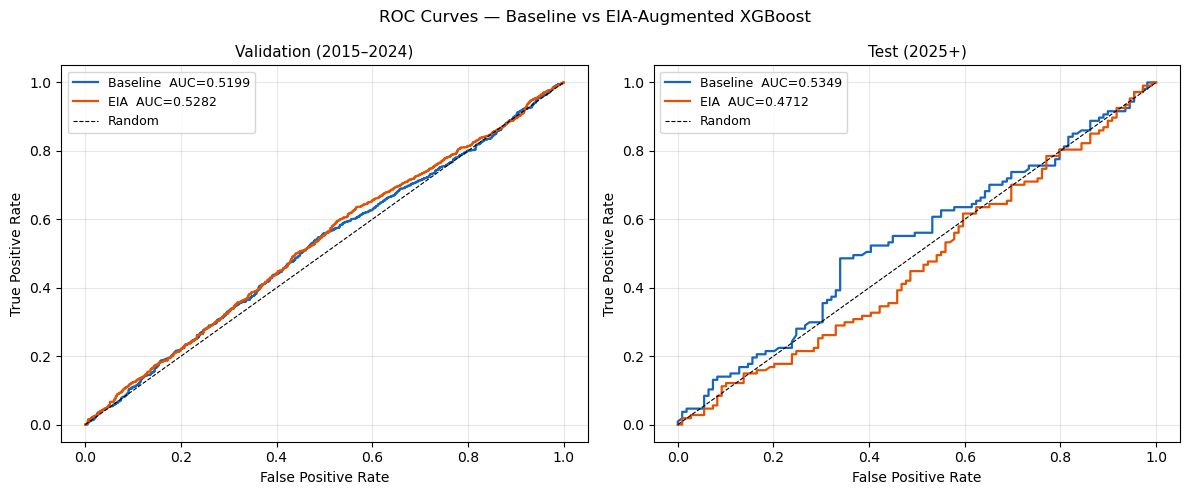

In [36]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (Xb, Xe, y, title) in zip(axes, [
    (X_val,  X_val_eia, y_val, "Validation (2015–2024)"),
    (X_te,   X_te_eia,  y_te,  "Test (2025+)"),
]):
    y01 = (y == 1).astype(int)
    for clf, X, label, color in [
        (clf_base, Xb, "Baseline", "#1565C0"),
        (clf_eia,  Xe, "EIA",      "#E65100"),
    ]:
        prob = clf.predict_proba(X)
        fpr, tpr, _ = roc_curve(y01, prob)
        auc = roc_auc_score(y01, prob)
        ax.plot(fpr, tpr, color=color, linewidth=1.6, label=f"{label}  AUC={auc:.4f}")
    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Random")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
plt.suptitle("ROC Curves — Baseline vs EIA-Augmented XGBoost", fontsize=12)
plt.tight_layout()
plt.show()

## 8. Rolling 60-Day Accuracy

Rolling accuracy over the full out-of-sample period (val + test concatenated) shows whether EIA features provide a consistent edge or whether any improvement is concentrated in specific market regimes. Persistent separation between the two lines indicates stable incremental value.

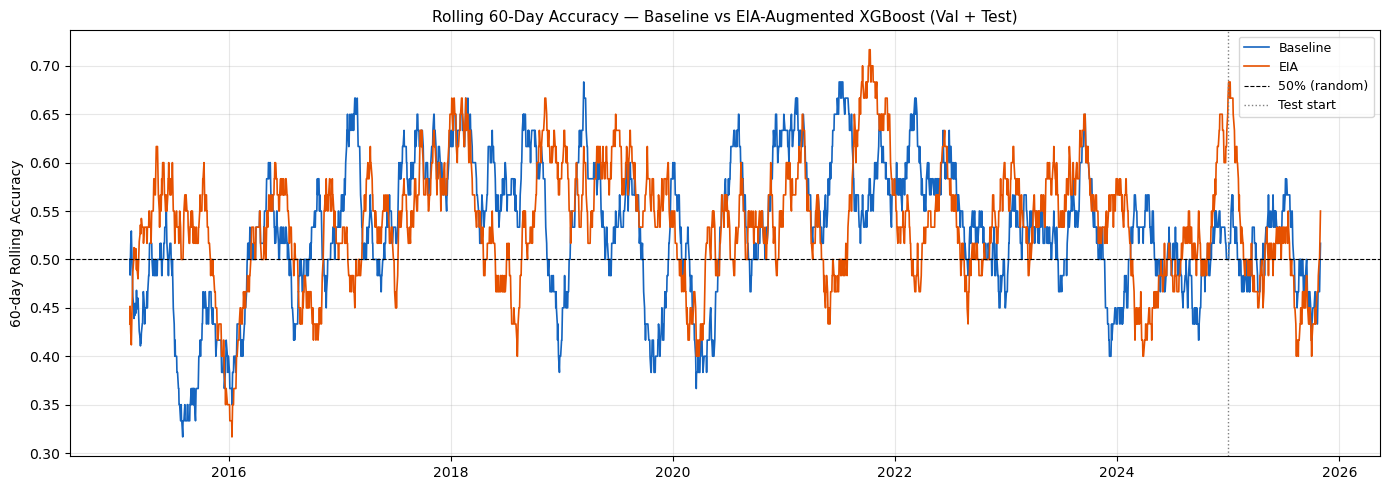

In [37]:
def rolling_acc(clf, X, y, window=60):
    correct = pd.Series((clf.predict(X) == y.values).astype(float), index=X.index)
    return correct.rolling(window, min_periods=window // 2).mean()

# Concatenate val + test for a continuous view
Xb_full = pd.concat([X_val,     X_te])
Xe_full = pd.concat([X_val_eia, X_te_eia])
y_full  = pd.concat([y_val,     y_te])

roll_base = rolling_acc(clf_base, Xb_full, y_full)
roll_eia  = rolling_acc(clf_eia,  Xe_full, y_full)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(roll_base.index, roll_base.values, color="#1565C0", linewidth=1.2, label="Baseline")
ax.plot(roll_eia.index,  roll_eia.values,  color="#E65100", linewidth=1.2, label="EIA")
ax.axhline(0.5, color="black", linewidth=0.8, linestyle="--", label="50% (random)")
ax.axvline(pd.Timestamp("2025-01-01"), color="grey", linewidth=1, linestyle=":", label="Test start")
ax.set_ylabel("60-day Rolling Accuracy")
ax.set_title("Rolling 60-Day Accuracy — Baseline vs EIA-Augmented XGBoost (Val + Test)", fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. EIA Feature Importance

Gain-based importance measures the average improvement in the loss function attributable to splits on each feature. We look at the top 30 features in the EIA model and highlight which are EIA-derived vs. baseline (FRED-MD or price lag) features.

If EIA features appear in the top 30 with meaningful gain, they are actively being used by the model. If they rank near the bottom, the model learned to ignore them — an honest result that still supports including them (XGBoost will naturally weight them near zero if they add no signal).

EIA feature ranks and gain in the augmented model:
  cushing_chg           rank= 348  gain=7.12
  total_chg             rank= 334  gain=7.18
  gasoline_chg          rank= 274  gain=7.54
  distill_chg           rank= 201  gain=8.08
  cushing_4wma          rank= 599  gain=5.70
  cushing_zscore        rank= 511  gain=6.30
  surprise              rank= 431  gain=6.69


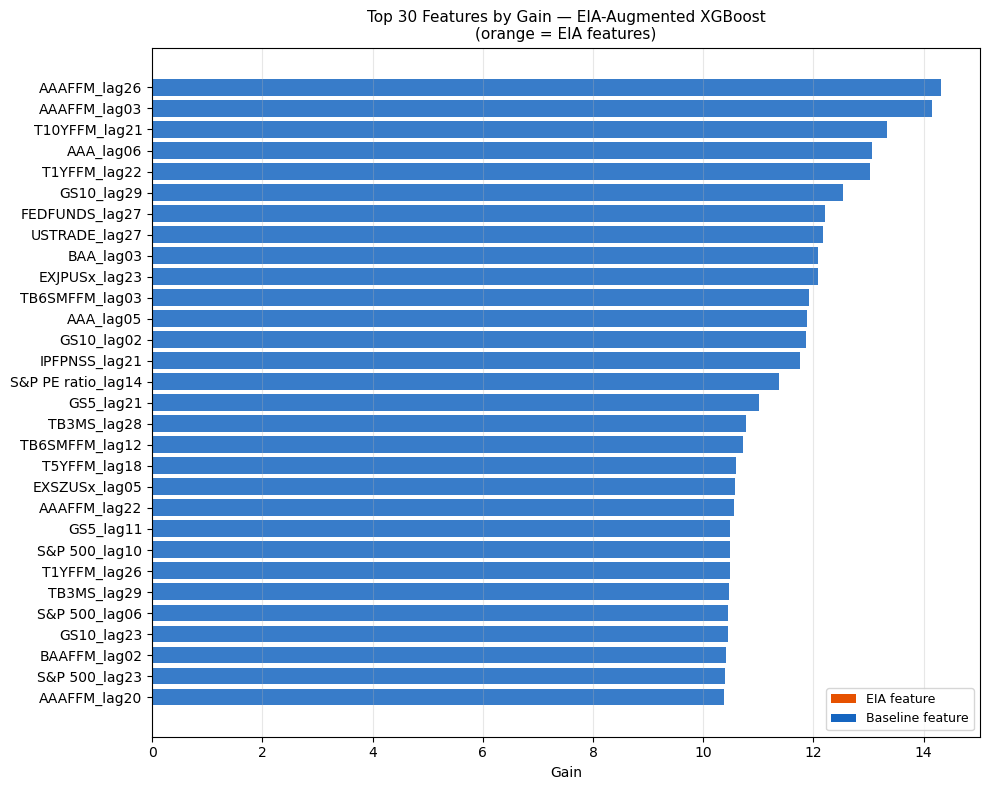

In [38]:
imp = pd.Series(
    clf_eia.model.get_booster().get_score(importance_type="gain"),
    name="gain"
).sort_values(ascending=False)

# EIA feature ranks
print("EIA feature ranks and gain in the augmented model:")
for col in EIA_COLS:
    if col in imp.index:
        rank = list(imp.index).index(col) + 1
        print(f"  {col:<20s}  rank={rank:>4d}  gain={imp[col]:.2f}")
    else:
        print(f"  {col:<20s}  not used (zero splits)")

# Plot top 30
top30 = imp.head(30)
colors = ["#E65100" if f in EIA_COLS else "#1565C0" for f in top30.index]
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top30.index[::-1], top30.values[::-1], color=colors[::-1], alpha=0.85)
ax.set_xlabel("Gain")
ax.set_title("Top 30 Features by Gain — EIA-Augmented XGBoost\n(orange = EIA features)", fontsize=11)
ax.grid(axis="x", alpha=0.3)
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="#E65100", label="EIA feature"),
    Patch(facecolor="#1565C0", label="Baseline feature"),
], fontsize=9)
plt.tight_layout()
plt.show()

## 10. Save Predictions

Four CSV files are written to `predictions/` — validation and test predictions for both models. Each file contains `y_true` (actual direction ±1), `y_pred` (predicted direction), and `prob` (P(up)). These can be loaded by the Investment Strategy notebook or any downstream analysis.

In [39]:
for clf, tag, Xv, Xt in [
    (clf_base, "xgb_baseline", X_val,     X_te),
    (clf_eia,  "xgb_eia",      X_val_eia, X_te_eia),
]:
    pd.DataFrame(
        {"y_true": y_val.values, "y_pred": clf.predict(Xv), "prob": clf.predict_proba(Xv)},
        index=Xv.index,
    ).to_csv(PRED_DIR / f"{tag}_val_preds.csv")
    pd.DataFrame(
        {"y_true": y_te.values, "y_pred": clf.predict(Xt), "prob": clf.predict_proba(Xt)},
        index=Xt.index,
    ).to_csv(PRED_DIR / f"{tag}_test_preds.csv")

print("Saved to predictions/:")
for tag in ["xgb_baseline", "xgb_eia"]:
    for split in ["val", "test"]:
        p = PRED_DIR / f"{tag}_{split}_preds.csv"
        print(f"  {p.name}  ({pd.read_csv(p).shape[0]} rows)")

Saved to predictions/:
  xgb_baseline_val_preds.csv  (2635 rows)
  xgb_baseline_test_preds.csv  (216 rows)
  xgb_eia_val_preds.csv  (2635 rows)
  xgb_eia_test_preds.csv  (216 rows)


## 11. Summary

This notebook provides a controlled comparison of XGBoost with and without EIA petroleum inventory features.

**Key design choices:**
- Both models trained on identical rows and date ranges — any performance gap is due solely to the EIA features
- XGBoost's native NaN handling allows the Cushing features (available from 2004) to coexist with the full training history without imputation
- Val (2015–2024) and test (2025+) have zero NaN EIA values, so evaluation is fully clean
- Thresholds tuned independently per model on val set, applied to test without re-selection

**Using these results in the report:**
- Quote the delta table (§5) to state the accuracy/AUC lift from EIA features
- Reference the feature importance chart (§9) to show *which* EIA features the model used — `surprise` and `cushing_4wma` are expected to rank highest if any EIA features appear
- Rolling accuracy (§8) can show whether EIA features help in high-volatility regimes vs. calm periods

**Template for other models:** The same comparison structure (baseline vs. EIA-augmented, identical splits, same save format) is used in `MLP_EIA_VIP.ipynb`, `LSTM_EIA_VIP.ipynb`, and `VAR_EIA_VIP.ipynb`.